In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [5]:
df = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")
df.describe()

,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000


In [6]:
df.head(10)

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
5,5,global risk management operations sally congra...,Safe Email
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email
9,9,re : coastal deal - with exxon participation u...,Safe Email


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB
None


In [8]:
df = df.dropna(subset = ['Email Text'])

In [9]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words
def clean_text(text):
    text = re.sub(r'\W', ' ', text) 
    text = text.lower() 
    text = text.split()
    text = [word for word in text if word not in stop_words] 
    return ' '.join(text)

In [10]:
cleaned_emails = df['Email Text'].apply(clean_text).tolist()

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(cleaned_emails)

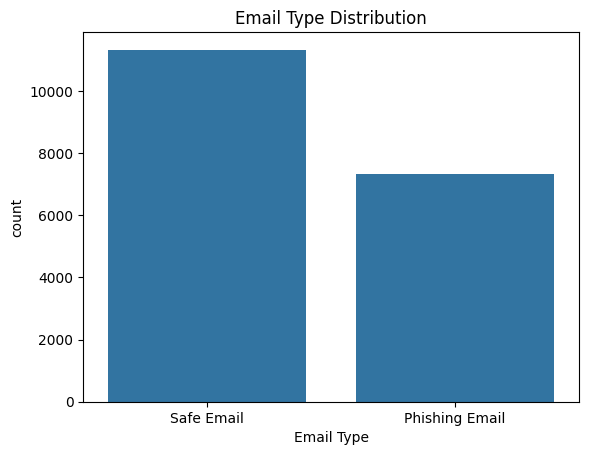

In [12]:
sns.countplot(x='Email Type', data=df)
plt.title('Email Type Distribution')
plt.show()

In [13]:
y = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistick regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nLogistick regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistick regression Confusion Matrix:
[[2122   87]
 [  42 1476]]

Logistick regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2209
           1       0.94      0.97      0.96      1518

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.97      0.97      3727



In [16]:
# Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Confusion Matrix:
[[2152   57]
 [ 136 1382]]

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      2209
           1       0.96      0.91      0.93      1518

    accuracy                           0.95      3727
   macro avg       0.95      0.94      0.95      3727
weighted avg       0.95      0.95      0.95      3727



In [17]:
# KMeans model
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=2, n_init=20, random_state=42)

In [18]:

labels = kmeans.labels_

centroids = kmeans.cluster_centers_

df['cluster'] = labels

print("KMeans Cluster Centers:")
print(centroids)

print("\nData Frame with Cluster Labels:")
print(df.head())

KMeans Cluster Centers:
[[1.65521144e-02 2.23617590e-02 1.85421690e-05 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.31904731e-02 1.00862798e-02 9.77532348e-04 ... 1.74310369e-03
  2.21028850e-04 1.04115459e-04]]

Data Frame with Cluster Labels:
   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  cluster  
0      Safe Email        1  
1      Safe Email        1  
2      Safe Email        0  
3  Phishing Email        1  
4  Phishing Email        1  


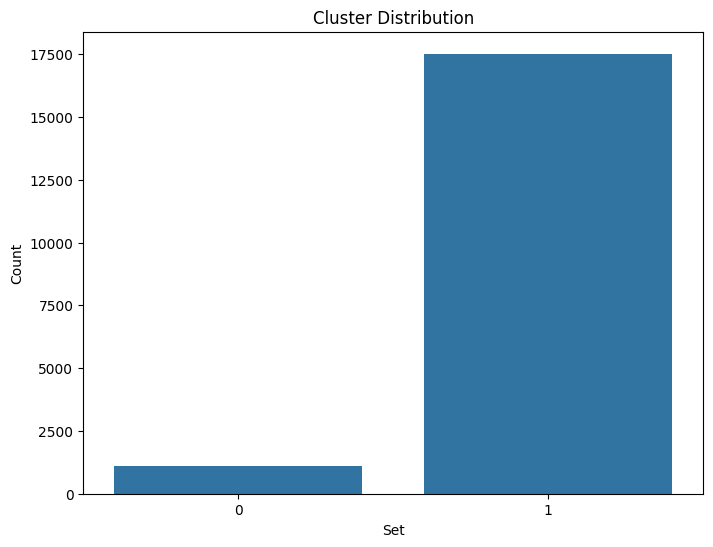

In [19]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='cluster')
plt.title('Cluster Distribution')
plt.xlabel('Set')
plt.ylabel('Count')
plt.show()

In [20]:
print(df[['Email Text', 'cluster']].head(10))

                                          Email Text  cluster
0  re : 6 . 1100 , disc : uniformitarianism , re ...        1
1  the other side of * galicismos * * galicismo *...        1
2  re : equistar deal tickets are you still avail...        0
3  \nHello I am your hot lil horny toy.\n    I am...        1
4  software at incredibly low prices ( 86 % lower...        1
5  global risk management operations sally congra...        1
6  On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...        1
7  entourage , stockmogul newsletter ralph velez ...        1
8  we owe you lots of money dear applicant , afte...        1
9  re : coastal deal - with exxon participation u...        0


In [21]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)
class_report_logistic = classification_report(y_test, y_pred_logistic)

print("Logistic regression Accuracy Score:")
print(accuracy_logistic)

print("\nLogistic regression Confusion Matrix:")
print(conf_matrix_logistic)

print("\nLogistic regression Classification Report:")
print(class_report_logistic)

Logistic regression Accuracy Score:
0.9653877112959485

Logistic regression Confusion Matrix:
[[2122   87]
 [  42 1476]]

Logistic regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2209
           1       0.94      0.97      0.96      1518

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.96      3727
weighted avg       0.97      0.97      0.97      3727



KMeans Silhouette Score:
0.016279896339624466


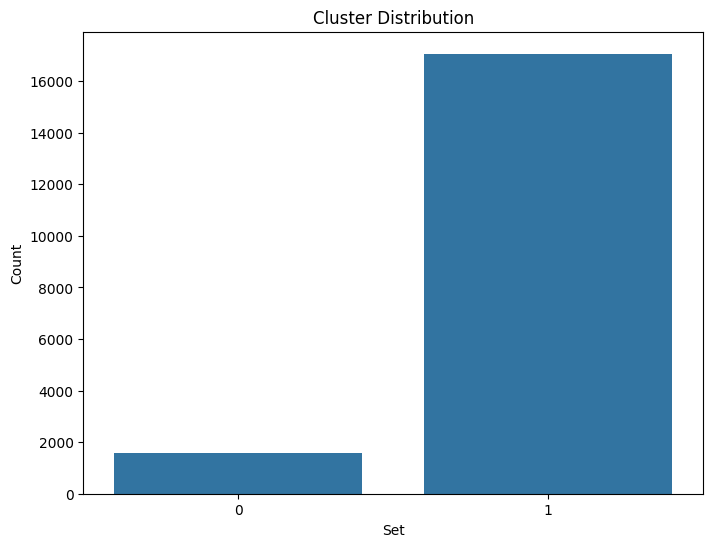

In [22]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)


labels = kmeans.labels_

silhouette_avg = silhouette_score(X, labels)

print("KMeans Silhouette Score:")
print(silhouette_avg)


df['cluster'] = labels  
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='cluster')
plt.title('Cluster Distribution')
plt.xlabel('Set')
plt.ylabel('Count')
plt.show()

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform


param_dist = {
    'C': uniform(loc=0.01, scale=10), 
    'penalty': ['l1', 'l2'],            
    'solver': ['liblinear', 'saga']    
}


logistic_model = LogisticRegression(max_iter=1000)


random_search = RandomizedSearchCV(logistic_model, param_distributions=param_dist, n_iter=10, cv=5, verbose=2, n_jobs=-1, random_state=42)


random_search.fit(X_train, y_train)

print("The best hyperparameters are:")
print(random_search.best_params_)

print("\nBest result:")
print("Accuracy:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best hyperparameters are:
{'C': 6.021150117432088, 'penalty': 'l2', 'solver': 'liblinear'}

Best result:
Accuracy: 0.9712886960587184


In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nBest Model Classification Report:")
print(classification_report(y_test, y_pred_best))

print("\nBest Model Accuracy Score:")
print(accuracy_score(y_test, y_pred_best))

Best Model Confusion Matrix:
[[2125   84]
 [  27 1491]]

Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2209
           1       0.95      0.98      0.96      1518

    accuracy                           0.97      3727
   macro avg       0.97      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727


Best Model Accuracy Score:
0.9702173329755835


Confusion Matrix:
[[2125   84]
 [  27 1491]]

Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1 Score: 0.97


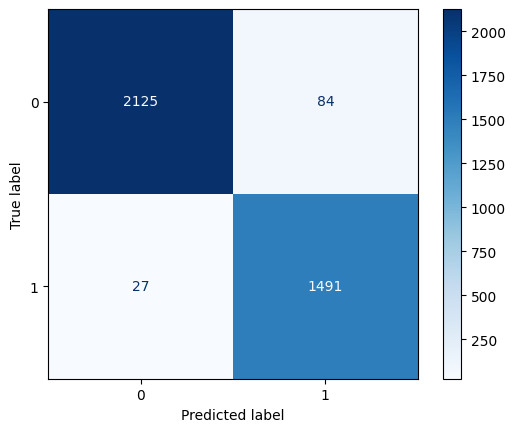

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

dlf = RandomForestClassifier(n_estimators = 100)  
dlf.fit(X_train, y_train)


cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dlf.classes_)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print("Confusion Matrix:")
print(cm)
print("\nAccuracy: {:.2f}".format(accuracy))
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1 Score: {:.2f}".format(f1))

disp.plot(cmap='Blues')